Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
tf.Tensor(
[[1. 2. 3.]
 [4. 5. 6.]], shape=(2, 3), dtype=float32)
(2, 3)
<dtype: 'float32'>
tf.Tensor(
[[ 2.  4.  6.]
 [ 8. 10. 12.]], shape=(2, 3), dtype=float32)
tf.Tensor(
[[10. 20. 30.]
 [40. 50. 60.]], shape=(2, 3), dtype=float32)
tf.Tensor(
[[10. 40.]
 [20. 50.]
 [30. 60.]], shape=(3, 2), dtype=float32)
tf.Tensor(
[[10. 20. 30.]
 [40. 50. 60.]], shape=(2, 3), dtype=float32)
tf.Tensor(
[[1400. 3200.]
 [3200. 7700.]], shape=(2, 2), dtype=float32)
tf.Tensor(
[[10. 20. 30.]
 [40. 50. 60.]
 [10. 20. 30.]
 [40. 50. 60.]
 [10. 20. 30.]
 [40. 50. 60.]], shape=(6, 3), dtype=float32)
tf.Tensor(
[[2.061060e-09 4.539787e-05 9.999546e-01]
 [2.061060e-09 4.539787e-05 9.999546e-01]], shape=(2, 3), dtype=float32)
tf.Tensor(210.0, shape=(), dtype=float32)
tf.Tensor(
[[10. 20. 30.]
 [40. 50. 60.]], shape=(2, 3), dtype=float32)
TensorFlow **IS NOT** using the GPU
Evaluaci

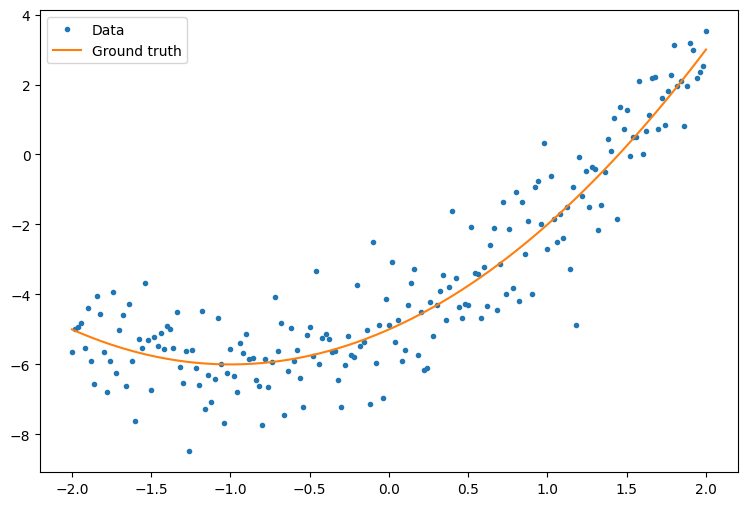

In [2]:
import tensorflow as tf
from google.colab import drive
drive.mount('/content/drive')


# Tensores
x = tf.constant([[1., 2., 3.],
                 [4., 5., 6.]])

print(x)
print(x.shape)
print(x.dtype)

x  = x + x
print(x)

x = 5 * x
print(x)

print(tf.transpose(x))

y = x @ tf.transpose(x)

print(x)

print(y)

print(tf.concat([x, x, x], axis=0))

print(tf.nn.softmax(x, axis=-1))

print(tf.reduce_sum(x))

print(x)

if tf.config.list_physical_devices('GPU'):
  print("TensorFlow **IS** using the GPU")
else:
  print("TensorFlow **IS NOT** using the GPU")

# Variables

var = tf.Variable([0.0, 0.0, 0.0])

var.assign([1, 2, 3])

var.assign_add([1, 1, 1])

# Diferenciación automática
x = tf.Variable(1.0)

def f(x):
  y = x**2 + 2*x - 5
  return y

print(f'Evaluación inicial:{f(x)}')

# Derivada

with tf.GradientTape() as tape:
  y = f(x)

g_x = tape.gradient(y, x)  # g(x) = dy/dx

print(f'Evaluación 1ra. derivada:{g_x}')

# Gráficos y función tf.
@tf.function
def my_func(x):
  print('Tracing.\n')
  return tf.reduce_sum(x)

# Evaluación inicial
x = tf.constant([1, 2, 3])
print(f'Resultado evaluación inicial :{my_func(x)}')

# Primera evaluación
x = tf.constant([10, 9, 8])
print(f'Resultado Primera evaluación :{my_func(x)}')

# Segunda evaluación
x = tf.constant([10.0, 9.1, 8.2], dtype=tf.float32)
print(f'Resultado Segunda evaluación :{my_func(x)}')

# Módulos, capas y modelos
class MyModule(tf.Module):
  def __init__(self, value):
    self.weight = tf.Variable(value)

  @tf.function
  def multiply(self, x):
    return x * self.weight

mod = MyModule(3)

print(f'Resultado del módulo :{mod.multiply(tf.constant([1, 2, 3]))}')

# Guardar el módulo
import os

# 1. Define la ruta de la carpeta donde quieres guardar el SavedModel
# Asegúrate de usar una ruta completa dentro de tu Drive montado
save_path = '/content/drive/MyDrive/modelos/saved_model_folder'

# 2. Verifica y crea el directorio si no existe
if not os.path.exists(save_path):
    os.makedirs(save_path)

# 3. Guarda el modelo
tf.saved_model.save(mod, save_path)

print(f"Modelo guardado exitosamente en: {save_path}")


# Guardar en Google Colab
# save_path = './saved'
# tf.saved_model.save(mod, save_path)

# Recuperar el módulo
reloaded = tf.saved_model.load(save_path)
print(f'Resultado de la ejecución del módulo guardado : {reloaded.multiply(tf.constant([1, 2, 3]))}')

# Bucles de entrenamiento
import matplotlib
from matplotlib import pyplot as plt

matplotlib.rcParams['figure.figsize'] = [9, 6]


x = tf.linspace(-2, 2, 201)
x = tf.cast(x, tf.float32)

def f(x):
  y = x**2 + 2*x - 5
  return y

y = f(x) + tf.random.normal(shape=[201])

plt.plot(x.numpy(), y.numpy(), '.', label='Data')
plt.plot(x, f(x),  label='Ground truth')
plt.legend();

